In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from utils.iea22s import IEA22s
from utils.sites import Hornsrev1Site

# this is a smoother version of PyWake IEA22 that works better with wake steering optimization
wt = IEA22s()
wds = np.arange(0, 360, 2)
wss = np.arange(3, 25, 1)
(x, y), site = Hornsrev1Site(
    scale_D=wt.diameter()  # scale up the layout based on turbine diameter ratio
)
TI = 0.04  # site.local_wind().TI_ilk.ravel()s
n_threads = 1

In [3]:
from utils.easy import easy_yaw_gnn
# this should work with PyWake-style inputs
yaws = easy_yaw_gnn(x, y, wd=wds, ws=wss, TI=TI, num_threads=n_threads, batch_size=len(wds))

/tmp/dgodi_3932935_hyd/lib/python3.10/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
Converting to graphs: 100%|██████████| 3960/3960 [00:09<00:00, 414.35it/s]
INFO:design_friendly.utils.to_graph: generated 3960 graphs from 3960 cases
INFO:design_friendly.utils.to_graph: generate_graphs took 9.562 s
INFO:design_friendly.utils.to_graph: graph_maker_lut took 9.565 s
/home/dgodi/ActiveProjects/design_friendly_control/design-friendly-control/design_friendly/utils/pred.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). I

Evaluating model /home/dgodi/ActiveProjects/design_friendly_control/design-friendly-control/design_friendly/models/best.pt


INFO:design_friendly.utils.pred: predict took 8.275 s
INFO:utils.easy: easy_yaw_gnn took 17.860 s


# Plot prediction results

In [4]:
# Report uplift
from utils.get_flowmodel import get_flowmodel

wf_model = get_flowmodel(wt=wt, site=site)

sim_base = wf_model(x=x, y=y, wd=wds, ws=wss, TI=TI, yaw=0, tilt=0, n_cpu=n_threads)
sim_gnn = wf_model(x=x, y=y, wd=wds, ws=wss, TI=TI, yaw=yaws, tilt=0, n_cpu=n_threads)

aep_base = sim_base.aep().sum().values
print(aep_base)
aep_gnn = sim_gnn.aep().sum().values
print(aep_gnn)
uplift = 100 * (aep_gnn - aep_base) / aep_base
print(f"AEP uplift: {uplift:.2f}%")

8263.395422082358
8343.645374250511
AEP uplift: 0.97%


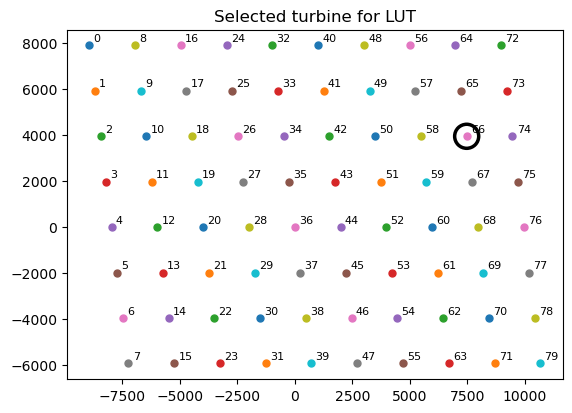

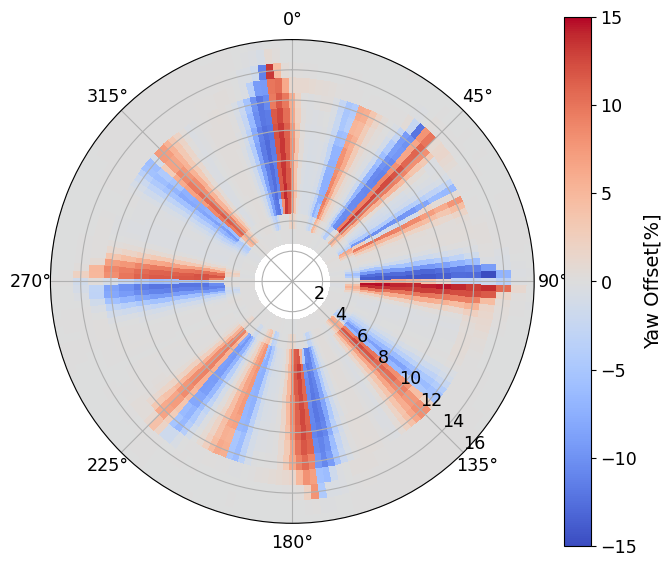

In [5]:
# plot look-up-table based on predictions
turbine_idx = int(66)  # select a turbine to plot

import matplotlib.pyplot as plt

plt.figure()
for i, (xi, yi) in enumerate(zip(x, y)):
    plt.scatter(xi, yi, s=25)
    plt.annotate(
        str(i),
        (xi, yi),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8,
    )
plt.gca().set_aspect("equal", adjustable="box")
plt.scatter(
    x[turbine_idx],
    y[turbine_idx],
    marker="o",
    facecolors="none",
    edgecolors="k",
    linewidths=2.5,
    s=300,
)
plt.title('Selected turbine for LUT')
plt.show()

# Plot LUT for turbine_idx
from utils.plot_utils import lut_3d_heatmap

lut_3d_heatmap(yaws[turbine_idx, :, :], wds=wds, wss=wss)

# Predict timeseries inputs

In [6]:
from design_friendly.models import models_filepath
from design_friendly.utils.pred import predict
from design_friendly.utils.to_graph import graph_maker_time

x = x
y = y
n_t = int(len(wds) * len(wss))  # set ts to genereate
wd = np.random.uniform(0, 360, n_t)
ws = np.random.uniform(3, 25, n_t)
TI = np.random.uniform(0.02, 0.14, n_t)
model_path = models_filepath + "best.pt"
num_threads = 0
batch_size = len(wd)  # adjust batch size in case of memory issues

In [7]:
from utils.easy import easy_yaw_gnn
yaws_t = easy_yaw_gnn(x, y, wd=wd, ws=ws, TI=TI, num_threads=n_threads, batch_size=len(wd), time=True)

Converting to graphs: 100%|██████████| 3960/3960 [00:09<00:00, 404.94it/s]
INFO:design_friendly.utils.to_graph: generated 3960 graphs from 3960 cases
INFO:design_friendly.utils.to_graph: generate_graphs took 9.783 s
INFO:design_friendly.utils.to_graph: graph_maker_time took 9.789 s
/home/dgodi/ActiveProjects/design_friendly_control/design-friendly-control/design_friendly/utils/pred.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted

Evaluating model /home/dgodi/ActiveProjects/design_friendly_control/design-friendly-control/design_friendly/models/best.pt


INFO:design_friendly.utils.pred: predict took 5.825 s
INFO:utils.easy: easy_yaw_gnn took 15.633 s


# Plot time-series predictions

In [8]:
# try yaw on PyWake
from utils.get_flowmodel import get_flowmodel

n_threads = 16

wf_model = get_flowmodel(wt=wt, site=site)

sim_base = wf_model(x=x, y=y, wd=wd, ws=ws, TI=TI, yaw=0, tilt=0, n_cpu=n_threads, time=True)
sim_gnn = wf_model(x=x, y=y, wd=wd, ws=ws, TI=TI, yaw=yaws_t, tilt=0, n_cpu=n_threads, time=True)

aep_base = sim_base.aep().sum().values
print(aep_base)
aep_gnn = sim_gnn.aep().sum().values
print(aep_gnn)
uplift = 100 * (aep_gnn - aep_base) / aep_base
print(f"AEP uplift: {uplift:.2f}%")

11364.040680550652
11388.661489980697
AEP uplift: 0.22%


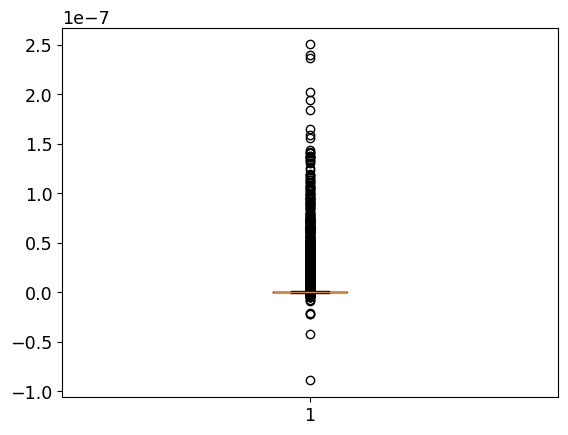

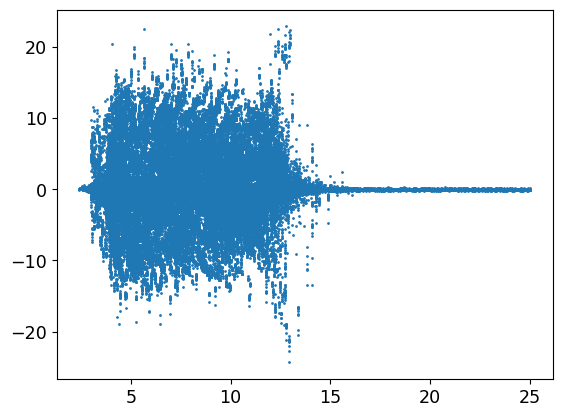

In [9]:
uplift = (sim_gnn.Power.sum("wt") - sim_base.Power.sum('wt')) / sim_base.Power.sum('wt')
plt.boxplot(uplift/1e6)
plt.show()
plt.scatter(sim_gnn.WS_eff.values, yaws_t, s=1)
plt.show()